In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from pathlib import Path
import requests
import numpy as np
from tqdm.auto import tqdm

In [ ]:
if Path("FashionMNIST").is_file():
  print("Model Exists")
else:
  inputs=input("Do you want to upload model?")
  if inputs.lower() in ['yes','yessss','ye','yeah','1']:
    from google.colab import files
    uploaded = files.upload()

Do you want to upload model?no


In [ ]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [ ]:
device='cuda' if torch.cuda.is_available() else 'cpu'
train_data=datasets.FashionMNIST(root='data',
                                 train=True,
                                 download=True,
                                 transform=train_transform,
                                 target_transform=None)
test_data=datasets.FashionMNIST(root='data',
                                train=False,
                                download=True,
                                transform=test_transform,
                                target_transform=None)

100%|██████████| 26.4M/26.4M [00:00<00:00, 109MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.71MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 58.2MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 32.3MB/s]


In [ ]:
image,labels=train_data[0]
image,labels

(tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.000

In [ ]:
class_names=train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_to_idx=train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

Text(0.5, 1.0, '9')

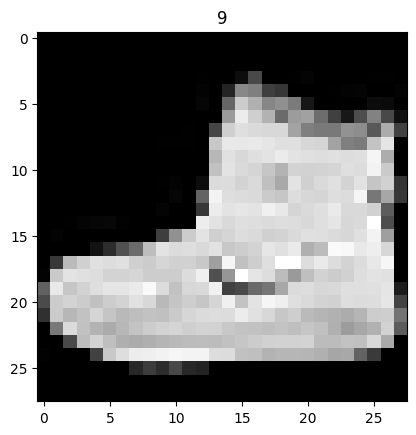

In [ ]:
image.squeeze().size()
plt.imshow(image.squeeze(),cmap='grey')
plt.title(labels)

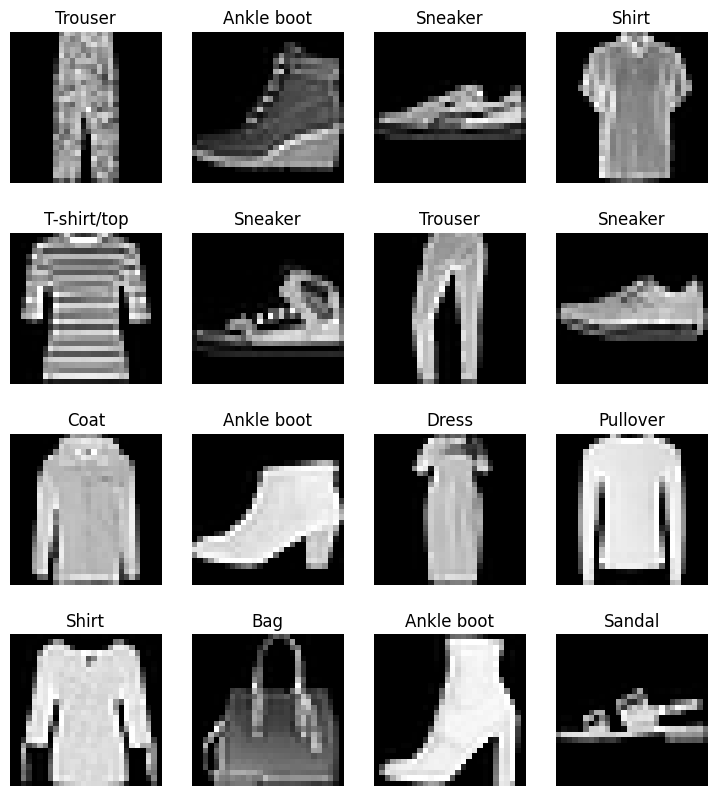

In [ ]:
torch.manual_seed(42)
plt.figure(figsize=(9,10))
rows,colms=4,4
for row in range(1,rows*colms+1):
  random_idx=torch.randint(low=0,high=len(test_data),size=[1]).item()
  img,label=train_data[random_idx]
  plt.subplot(rows,colms,row)
  plt.title(class_names[label])
  plt.imshow(img.squeeze(),cmap='grey')
  plt.axis(False)

In [ ]:
train_dataloader=DataLoader(train_data,batch_size=32,shuffle=True)
test_dataloader=DataLoader(test_data,batch_size=32,shuffle=True)
train_features_batch1,train_labels_batch1=next(iter(train_dataloader))

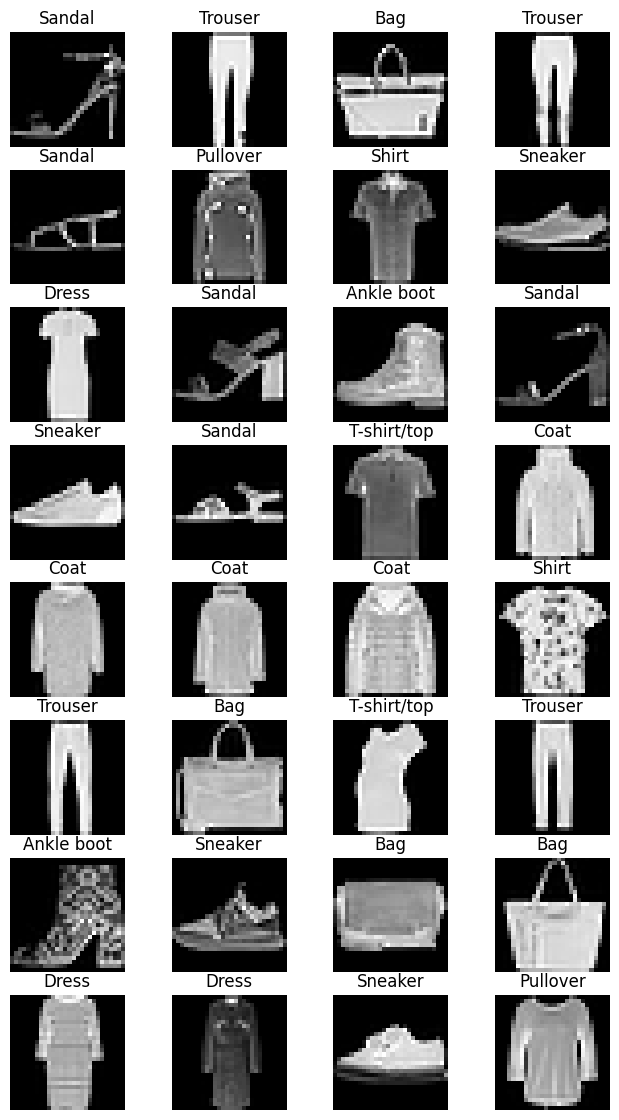

In [ ]:
torch.manual_seed(42)
rows,colms=8,4
plt.figure(figsize=(8,14))
for row in range(1,rows*colms+1):
  #random_idx=torch.randint(low=0,high=len(train_features_batch1),size=[1]).item()
  img,label=train_features_batch1[row-1],train_labels_batch1[row-1]
  plt.subplot(rows,colms,row)
  plt.imshow(img.squeeze(),cmap='grey')
  plt.title(class_names[label])
  plt.axis(False)

In [ ]:
class Classifier(nn.Module):
  def __init__(self,hidden_layers,output_shape=1):
    super().__init__()
    self.layer_stack=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=784,out_features=hidden_layers),
        nn.ReLU(),
        nn.Linear(in_features=hidden_layers,out_features=output_shape),
        nn.ReLU()
    )
  def forward(self,x):
    return self.layer_stack(x)

In [ ]:
torch.manual_seed(42)
model0=Classifier(hidden_layers=1000,
                  output_shape=len(class_names))
dummyz=torch.rand([1,1,28,28])
model0(dummyz).to(device)
x=nn.Flatten()

In [ ]:
optimizer=torch.optim.SGD(params=model0.parameters(),lr=0.1)
loss_fn=nn.CrossEntropyLoss()


In [ ]:
def accuracy_fn(Y_pred,Y_true):
  count=torch.eq(Y_pred,Y_true).sum().item()
  return count/len(Y_pred)*100

In [ ]:
if not Path('FashionMNIST').is_file():
  loss1=[]
  epoch1=[]
  accuracy=[]
  batches=1875
  model0.to(device)
  epochs=25
  for epoch in tqdm(range(epochs)):
    count=0
    loss0 = 0
    accuraxy0 = 0
    for train_features_batch1,train_labels_batch1 in train_dataloader:
      count+=1
      train_features_batch1=train_features_batch1.to(device)
      train_labels_batch1=train_labels_batch1.to(device)
      model0.train()
      y_logits=model0(train_features_batch1)
      y_preds=torch.softmax(y_logits,dim=1).argmax(dim=1)
      loss=loss_fn(y_logits,train_labels_batch1)
      accuraxy=accuracy_fn(y_preds,train_labels_batch1)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      model0.eval()
      loss0+=loss.item()
      accuraxy0+=accuraxy
    loss1.append(loss0/len(train_dataloader))
    epoch1.append(epoch)
    accuracy.append(accuraxy0/len(train_dataloader))

  0%|          | 0/25 [00:00<?, ?it/s]

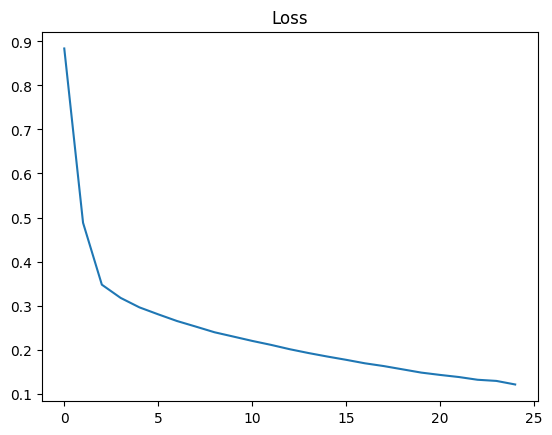

In [ ]:
if not Path('FashionMNIST').is_file():
  plt.plot(epoch1,torch.Tensor(loss1).cpu())
  plt.title("Loss")

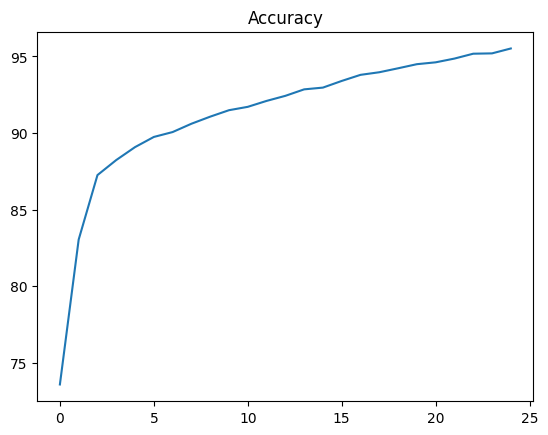

In [ ]:
if not Path('FashionMNIST').is_file():
  plt.plot(epoch1,torch.Tensor(accuracy).cpu())
  plt.title("Accuracy")

In [ ]:
torch.save(model0,"FashionMNIST")

In [ ]:
model = torch.load("FashionMNIST", weights_only=False).to(device)

In [ ]:
with torch.inference_mode():
  batch=[]
  bacth=0
  accuracy=[]
  loss=[]
  for test_features_batch1,test_labels_batch1 in test_dataloader:
    bacth+=1
    test_features_batch1=test_features_batch1.to(device)
    test_labels_batch1=test_labels_batch1.to(device)
    test_logits=model(test_features_batch1)
    test_pred=torch.softmax(test_logits,dim=1).argmax(dim=1)
    test_loss=loss_fn(test_logits,test_labels_batch1)
    test_accuracy=accuracy_fn(test_pred,test_labels_batch1)
    accuracy.append(test_accuracy)
    loss.append(test_loss)
    batch.append(bacth)
    print(f"Test Loss: {test_loss} Test Accuracy: {test_accuracy}")


Test Loss: 0.31942176818847656 Test Accuracy: 93.75
Test Loss: 0.34627455472946167 Test Accuracy: 84.375
Test Loss: 0.23611712455749512 Test Accuracy: 93.75
Test Loss: 0.4667244255542755 Test Accuracy: 90.625
Test Loss: 0.5319814085960388 Test Accuracy: 87.5
Test Loss: 0.1579446941614151 Test Accuracy: 93.75
Test Loss: 0.3742268681526184 Test Accuracy: 87.5
Test Loss: 0.6544612050056458 Test Accuracy: 81.25
Test Loss: 0.2550148367881775 Test Accuracy: 90.625
Test Loss: 0.3652709424495697 Test Accuracy: 87.5
Test Loss: 0.07301582396030426 Test Accuracy: 96.875
Test Loss: 0.44991829991340637 Test Accuracy: 84.375
Test Loss: 0.12822368741035461 Test Accuracy: 93.75
Test Loss: 0.526077926158905 Test Accuracy: 90.625
Test Loss: 0.2063210904598236 Test Accuracy: 90.625
Test Loss: 0.23194697499275208 Test Accuracy: 90.625
Test Loss: 0.6892784237861633 Test Accuracy: 84.375
Test Loss: 0.03675660490989685 Test Accuracy: 100.0
Test Loss: 0.5927409529685974 Test Accuracy: 81.25
Test Loss: 0.54726

Text(0.5, 1.0, 'Batch Test Loss')

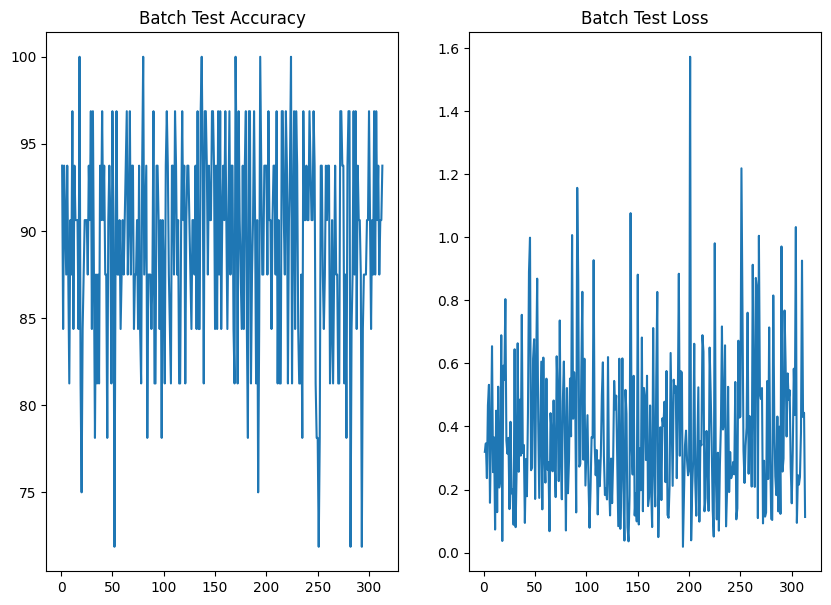

In [ ]:
#Realised that this is pretty much meaningless
plt.figure(figsize=(10,7))
plt.subplot(1,2,1)
plt.plot(batch,accuracy)
plt.title("Batch Test Accuracy")
plt.subplot(1,2,2)
plt.plot(batch,torch.Tensor(loss).cpu())
plt.title("Batch Test Loss")

In [ ]:
test_accuracy=np.mean(accuracy)
test_loss=np.mean([l.item() for l in loss])
print(f'Overall Test Accuracy: {test_accuracy}')
print(f'Overall Test Loss: {test_loss}')

Overall Test Accuracy: 89.41693290734824
Overall Test Loss: 0.3853308439326172


In [ ]:
#Building a Convolutional Neural Network
class FashionMNIST(nn.Module):
  #Based on the TinyVGG Architecture
  def __init__(self,input_shape,hidden_units,output_shape):
    super().__init__()
    self.conv_block_1=nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2=nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.Classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
        )
  def forward(self,x):
    return self.Classifier(self.conv_block_2(self.conv_block_1(x)))

In [ ]:
torch.manual_seed(42)
model2=FashionMNIST(input_shape=1,
                    hidden_units=32,
                    output_shape=len(class_names)).to(device)

In [ ]:
torch.manual_seed(42)
img=torch.randn(size=(32,3,64,64))
test_img=img[0]
conv_layer=nn.Conv2d(in_channels=3,
                     out_channels=10,
                     kernel_size=3,
                     stride=1,
                     padding=0)
conv_output=conv_layer(test_img)
print(conv_output.size())
max_pool_layer=nn.MaxPool2d(kernel_size=4)
conv_output=max_pool_layer(conv_output)
conv_output.size()

torch.Size([10, 62, 62])


torch.Size([10, 15, 15])

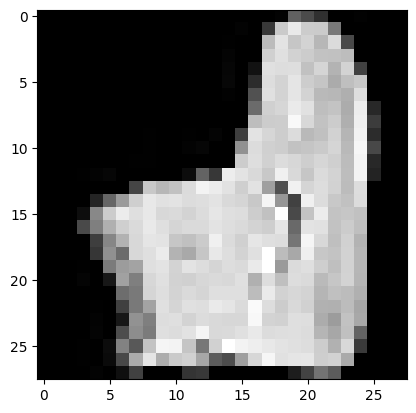

In [ ]:
plt.imshow(image.permute(2,1,0),cmap='grey')

In [ ]:
model2(image.unsqueeze(0).to(device))

tensor([[-0.0395,  0.0082, -0.0075,  0.0078, -0.0103,  0.0203,  0.0338, -0.0288,
          0.0514, -0.0678]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [ ]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=model2.parameters(),lr=1e-3)

In [ ]:
loss1=[]
epoch1=[]
accuracy=[]
batches=1875
model2.to(device)
epochs=3
for epoch in tqdm(range(epochs)):
  count=0
  loss0 = 0
  accuraxy0 = 0
  model2.train()
  for train_features_batch1,train_labels_batch1 in train_dataloader:
    count+=1
    train_features_batch1=train_features_batch1.to(device)
    train_labels_batch1=train_labels_batch1.to(device)
    y_logits=model2(train_features_batch1)
    y_preds=y_logits.argmax(dim=1)
    loss=loss_fn(y_logits,train_labels_batch1)
    accuraxy=accuracy_fn(y_preds,train_labels_batch1)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss0+=loss.item()
    accuraxy0+=accuraxy
  model2.eval()
  loss1.append(loss0/len(train_dataloader))
  epoch1.append(epoch)
  accuracy.append(accuraxy0/len(train_dataloader))

  0%|          | 0/3 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Loss')

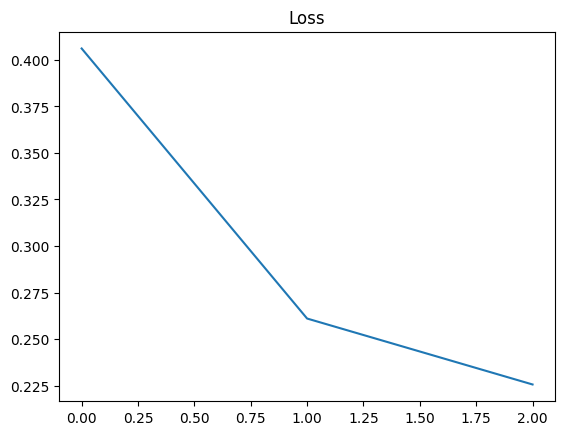

In [ ]:
plt.plot(epoch1,torch.Tensor(loss1).cpu())
plt.title("Loss")

Text(0.5, 1.0, 'Accuracy')

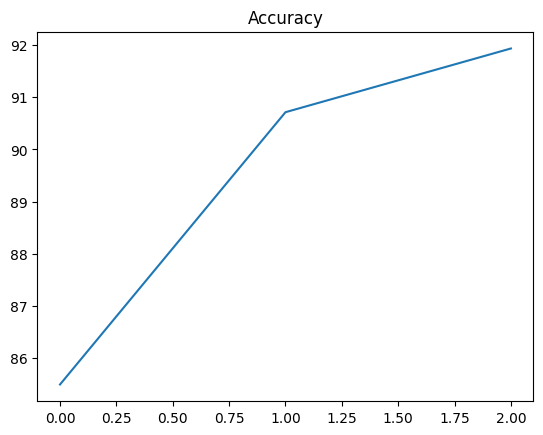

In [ ]:
plt.plot(epoch1,torch.Tensor(accuracy).cpu())
plt.title("Accuracy")

In [ ]:
with torch.inference_mode():
  batch=[]
  bacth=0
  accuracy=[]
  loss=[]
  for test_features_batch1,test_labels_batch1 in test_dataloader:
    bacth+=1
    test_features_batch1=test_features_batch1.to(device)
    test_labels_batch1=test_labels_batch1.to(device)
    test_logits=model2(test_features_batch1)
    test_pred=torch.softmax(test_logits,dim=1).argmax(dim=1)
    test_loss=loss_fn(test_logits,test_labels_batch1)
    test_accuracy=accuracy_fn(test_pred,test_labels_batch1)
    accuracy.append(test_accuracy)
    loss.append(test_loss)
    batch.append(bacth)

In [ ]:
test_accuracy=np.mean(accuracy)
test_loss=np.mean([l.item() for l in loss])
print(f'Overall Test Accuracy: {test_accuracy}')
print(f'Overall Test Loss: {test_loss}')

Overall Test Accuracy: 90.67492012779553
Overall Test Loss: 0.26539940499483394


In [ ]:
torch.save(model2,"FashionMNISTCNN")

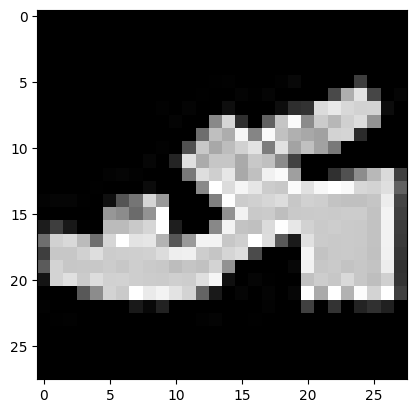

In [ ]:
import random
random.seed(42)
test_samples=[]
test_labels=[]
for sample,label in random.sample(list(test_data),k=9):
  test_samples.append(sample)
  test_labels.append(label)
plt.imshow(test_samples[0].squeeze(),cmap='grey')

In [ ]:
def making_predictions(model,data,device=device):
  predvalues=[]
  model.eval()
  with torch.inference_mode():
    for x in data:
      x=torch.unsqueeze(x,dim=0).to(device)
      pred_logits=model(x)
      pred_values=torch.softmax(pred_logits,dim=1).argmax(dim=1)
      predvalues.append(pred_values)
  return torch.stack(predvalues).squeeze()

In [ ]:
predictions=making_predictions(model=model2,data=test_samples)
print(predictions)
print(test_labels)
predictions[0]

tensor([5, 1, 7, 4, 3, 6, 4, 7, 1], device='cuda:0')
[5, 1, 7, 4, 3, 0, 4, 7, 1]


tensor(5, device='cuda:0')

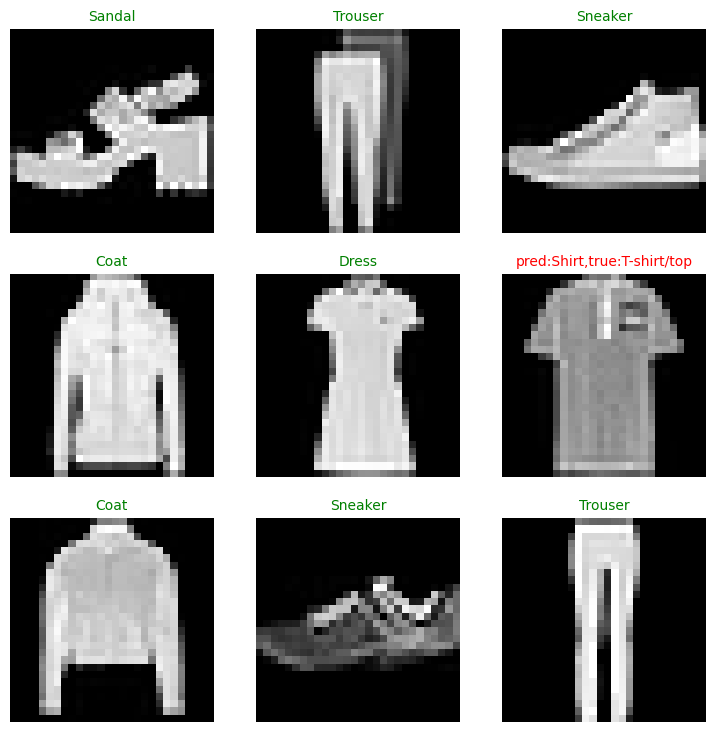

In [ ]:
plt.figure(figsize=(9,9))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(test_samples[i].squeeze(),cmap='gray')
  pred_labels=class_names[predictions[i].item()]
  true_labels=class_names[test_labels[i]]
  if pred_labels==true_labels:
    plt.title(true_labels,fontsize=10,c='g')
  else:
    plt.title(f'pred:{pred_labels},true:{true_labels}',fontsize=10,c='r')
  plt.axis(False)